Problem 1

The shuffled complex evolution (SCE) strategy combines the strengths of the controlled random search (CRS) algorithms with the concept of competitive evolution and the concept of complex shuffling.
1.	The step begins for this algorithm with categorizing the point s or parameter vectors into complexes the complex numbers cannot be less than the number of the parameters or dimensions. 
2.	After categorizing them, each vector point is tested on the function, and they are sorted in an ascending order of the function value. 
3.	Then each of those complex is evolved with the concept of competitive complex evaluation (CCE) and the worst point is replaced by a better point. 
4.	Then, all the points are again sorted in an ascending manner with the newly created points and tested on the function. 
5.	If the function satisfies the convergence criteria, then the process is stopped, otherwise the whole process is repeated until a satisfactory convergence is found.

The SCE method is designed to solve the following issues:
1.	There may be several regions of attraction into which a search strategy may converge
2.	Each major region of attraction may contain numerous local minima
3.	The objective function surface in the multiparameter space may not be smooth, convex shaped, or even continuous
4.	The parameters may exhibit varying degrees of sensitivity and a great deal of interaction and compensation
5.	The response surface near the true solution is often non-convex

Unlike gradient descent, which is a local optimization method that relies on derivatives to move “downhill” toward a minimum, SCE does not require gradient information and does not assume that the objective function is smooth or differentiable. Gradient descent is computationally efficient for well-behaved mathematical functions, but it is prone to getting trapped in local minima and performs poorly when the response surface is irregular or discontinuous. In contrast, SCE explores multiple regions of the parameter space simultaneously using a population of candidate solutions that are grouped into complexes and periodically shuffled. This structure allows SCE to escape local minima and perform a more robust global search, making it particularly suitable for hydrological models such as SWAT, where objective functions like NSE or KGE often produce irregular and noisy landscapes.
When compared to genetic algorithms (GA), SCE shares the idea of population-based search but differs in its mechanism of evolution. Genetic algorithms are inspired by biological evolution and use operators such as crossover and mutation to generate new candidate solutions. While GA is effective for global exploration, it often requires careful tuning of hyperparameters and may converge slowly or unstably in high-dimensional parameter spaces. SCE, on the other hand, combines competitive evolution with structured local search strategies, such as simplex methods, and periodically reshuffles complexes to maintain diversity while accelerating convergence. As a result, SCE typically converges faster and more reliably than traditional GA in hydrological calibration problems. Overall, SCE strikes a balance between global exploration and local refinement, making it more robust than gradient descent for nonlinear environmental models and often more efficient and stable than genetic algorithms in practical hydrological applications.



Problem 2
Regression for streamflow prediction

In [1]:
import os
os.getcwd()

'/Users/khrahaman@arizona.edu/computational_methods_course_khm_anik/Homework/Homework2'

In [3]:
import pandas as pd
df = pd.read_csv("../../data/LeafRiverDaily.csv")
df

,Precipitation,Temperature,Streamflow
0,0.0000,4.6004,0.289951
1,0.0000,4.3092,0.244761
2,0.0000,4.3286,0.213382
3,0.0000,4.7777,0.193298
4,0.0000,2.9110,0.183258
...,...,...,...
10955,0.0000,3.1170,0.144348
10956,0.0000,2.6248,0.148112
10957,0.0000,4.9893,0.148466
10958,0.0000,4.5724,0.142589


In [74]:
import numpy as np
window_size = 90
X = []
y = []

for i in range(len(df) -window_size):
    temp_window = df["Temperature"].iloc[i:i+window_size].values
    precip_window = df["Precipitation"].iloc[i:i+window_size].values
    features = np.concatenate([temp_window, precip_window])
    target = df["Streamflow"].iloc[i+window_size]
    X.append(features)
    y.append(target)

X = np.array(X)
y = np.array(y)
print(X.shape)
print(y.shape)


(10870, 180)
(10870,)


In [78]:
split_index = int(0.8 * len(X))

X_train = X[:split_index]
X_test  = X[split_index:]

y_train = y[:split_index]
y_test  = y[split_index:]

In [79]:
from sklearn.linear_model import LinearRegression
model.fit(X_train, y_train)


LinearRegression()

In [82]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print("R-squared:", r2)
print("Mean Absolute Error:", mae)

R-squared: 0.6755433530638681
Mean Absolute Error: 0.8781483939646927


/Users/khrahaman@arizona.edu/envs/jupyter_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/khrahaman@arizona.edu/envs/jupyter_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/khrahaman@arizona.edu/envs/jupyter_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


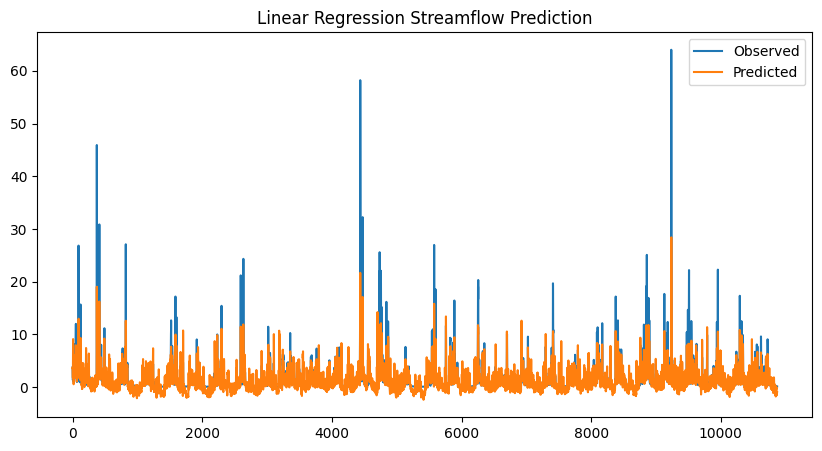

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y, label="Observed")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Linear Regression Streamflow Prediction")
plt.show()

Problem 3
calibration of a simple hydrological model

In [ ]:
import numpy as np
import pandas as pd

from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

import spotpy
from spotpy.parameter import Uniform
from spotpy.objectivefunctions import mse  

In [ ]:
df = pd.read_csv("../../data/LeafRiverDaily.csv")


P = df["Precipitation"].to_numpy(dtype=float)
T = df["Temperature"].to_numpy(dtype=float)
Qobs = df["Streamflow"].to_numpy(dtype=float)

n = len(df)
t_days = np.arange(n, dtype=float)

In [54]:
P_fun = interp1d(t_days, P, kind="previous", fill_value="extrapolate", bounds_error=False)
T_fun = interp1d(t_days, T, kind="previous", fill_value="extrapolate", bounds_error=False)

In [55]:
def run_bucket_model(a, b, c, S0=10.0):
    """
    Returns Qsim at daily times t_days (same length as input data).
    S0 is fixed (since assignment calibrates only a,b,c).
    """
    def rhs(t, y):
        S = max(y[0], 0.0)
        Pt = float(P_fun(t))
        Tt = float(T_fun(t))
        et = a * max(Tt, 0.0)
        q = b * (S ** c)
        dSdt = Pt - et - q
        return [dSdt]

    sol = solve_ivp(
        rhs,
        t_span=(t_days[0], t_days[-1]),
        y0=[S0],
        t_eval=t_days,
        method="RK45",
        rtol=1e-6,
        atol=1e-8,
    )

    S = np.maximum(sol.y[0], 0.0)
    Qsim = b * (S ** c)
    return Qsim

In [56]:
class SpotSetupBucket(object):
    def __init__(self, Qobs):
        self.Qobs = Qobs
        self.params = [
            Uniform("a", 0.0, 5.0),
            Uniform("b", 0.0, 1.0),
            Uniform("c", 0.5, 3.0),
        ]

    def parameters(self):
        return spotpy.parameter.generate(self.params)

    def simulation(self, vector):
        a, b, c = vector
        Qsim = run_bucket_model(a, b, c, S0=10.0)
        return Qsim

    def evaluation(self):
        return self.Qobs

    def objectivefunction(self, simulation, evaluation):
        # SCE-UA minimizes objective; MSE is perfect for minimization
        return mse(evaluation, simulation)

In [90]:
setup = SpotSetupBucket(Qobs)
sampler = spotpy.algorithms.sceua(setup, dbname="bucket_sceua", dbformat="csv")


sampler.sample(repetitions=1000)
results = sampler.getdata()

Initializing the  Shuffled Complex Evolution (SCE-UA) algorithm  with  1000  repetitions
The objective function will be minimized
Starting burn-in sampling...
1 of 1000, minimal objective function=22.192, time remaining: 01:10:37
Initialize database...
['csv', 'hdf5', 'ram', 'sql', 'custom', 'noData']
* Database file 'bucket_sceua.csv' created.
2 of 1000, minimal objective function=9.37431, time remaining: 01:13:15
3 of 1000, minimal objective function=9.37431, time remaining: 01:12:26
4 of 1000, minimal objective function=9.37431, time remaining: 02:34:08
5 of 1000, minimal objective function=9.37431, time remaining: 02:16:37
6 of 1000, minimal objective function=9.37431, time remaining: 02:08:57
7 of 1000, minimal objective function=9.37431, time remaining: 02:01:45
8 of 1000, minimal objective function=9.37431, time remaining: 02:45:36
9 of 1000, minimal objective function=8.12225, time remaining: 02:58:49
10 of 1000, minimal objective function=8.12225, time remaining: 02:46:58
11 o

In [91]:
best_index = np.argmin(results["like1"])  # like1 stores objective value (here MSE)
best = results[best_index]

best_a = best["para"]
best_b = best["parb"]
best_c = best["parc"]
best_mse = best["like1"]

print("Best parameters:")
print("a =", best_a)
print("b =", best_b)
print("c =", best_c)
print("MSE =", best_mse)

Qsim_best = run_bucket_model(best_a, best_b, best_c, S0=10.0)

Best parameters:
a = 0.9090459
b = 0.4056651
c = 0.89818335
MSE = 3.0893822


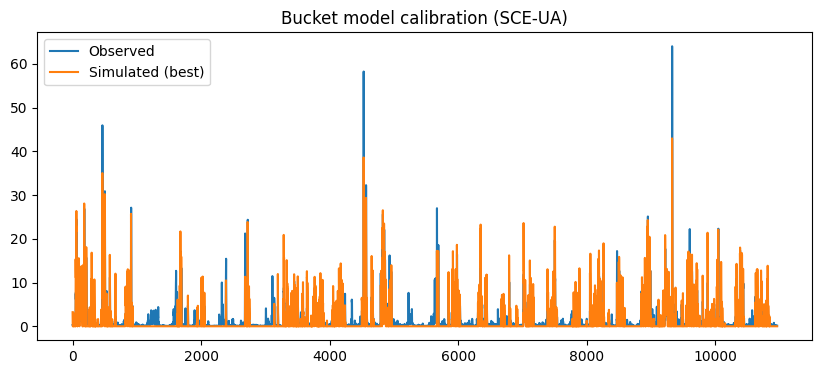

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(Qobs, label="Observed")
plt.plot(Qsim_best, label="Simulated (best)")
plt.legend()
plt.title("Bucket model calibration (SCE-UA)")
plt.show()

Problem 4: Comparison

In [93]:
import numpy as np

def nse(Qobs, Qpred):
    numerator = np.sum((Qobs - Qpred)**2)
    denominator = np.sum((Qobs - np.mean(Qobs))**2)
    return 1 - numerator / denominator

In [94]:
nse_lr = nse(y, y_pred)
print("Linear Regression NSE:", nse_lr)
nse_sce = nse(Qobs, Qsim_best)
print("SCE Model NSE:", nse_sce)

Linear Regression NSE: 0.6755433530638681
SCE Model NSE: 0.6185068993735454


The linear regression model performs better in terms of NSE (0.676) compared to the SCE-calibrated bucket model (0.618), indicating stronger predictive accuracy on the testing dataset. This suggests that the lagged temperature and precipitation inputs allowed the regression model to effectively capture streamflow variability.

Linear regression is simple, computationally efficient, and captures statistical relationships well, but it lacks physical interpretability and may not generalize well under changing climate conditions. The SCE bucket model, although slightly less accurate here, represents hydrological processes explicitly through storage dynamics and nonlinear discharge, making it more physically meaningful.

Performance of the regression model could be improved using nonlinear terms or regularization techniques, while the bucket model could be enhanced by refining parameter bounds, increasing calibration iterations, or incorporating additional hydrological processes.